# Notebook 04: análisis visual de tomografías

**RSNA 2022 Cervical Spine Fracture Detection**

El notebook ilustra ventanas radiológicas, cajas, reconstrucciones multiplanares,
segmentaciones y la dificultad visual de distinguir casos positivos y negativos.
Está diseñado para ejecutarse en Kaggle y exportar figuras reproducibles.

## 0. Preparación

Las selecciones de estudios son deterministas para que las figuras sean
reproducibles. La máscara se valida contra un estudio que tenga simultáneamente
bounding box y segmentación.

In [3]:
# Algunos DICOM usan JPEG Lossless y requieren un decodificador adicional.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("libjpeg") is None:
    print("Instalando soporte para DICOM JPEG Lossless...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "pylibjpeg>=2.0", "pylibjpeg-libjpeg>=2.1",
    ])
    importlib.invalidate_caches()
else:
    print("Decodificador JPEG Lossless disponible.")


Decodificador JPEG Lossless disponible.


In [4]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

KAGGLE = Path("/kaggle/input").exists()
PROJECT_ROOT = Path("/kaggle/working") if KAGGLE else Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

dataset_candidates = [
    Path("/kaggle/input/rsna-2022-cervical-spine-fracture-detection"),
    Path("/kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection"),
    PROJECT_ROOT / "dataset",
]
if KAGGLE:
    # Admite nombres personalizados de Input sin recorrer los 700 mil DICOM.
    dataset_candidates += [p.parent for p in Path("/kaggle/input").glob("*/train.csv")]
    dataset_candidates += [p.parent for p in Path("/kaggle/input").glob("*/*/train.csv")]
BASE = next((p for p in dataset_candidates
             if (p / "train.csv").is_file()
             and (p / "train_bounding_boxes.csv").is_file()), None)
if BASE is None:
    mounted = [p.name for p in Path("/kaggle/input").iterdir()] if KAGGLE else []
    raise FileNotFoundError(
        "No se encontró el dataset RSNA 2022. En Kaggle usa Add Input > "
        "Competition Data > RSNA 2022 Cervical Spine Fracture Detection y "
        f"vuelve a ejecutar. Inputs montados actualmente: {mounted or 'ninguno'}"
    )
TRAIN_IMAGES = BASE / "train_images"
SEGMENTATIONS = BASE / "segmentations"
FIGURES = Path("/kaggle/working/figures") if KAGGLE else PROJECT_ROOT / "figures"
DATA_OUT = Path("/kaggle/working/data") if KAGGLE else PROJECT_ROOT / "data"
FIGURES.mkdir(parents=True, exist_ok=True)
DATA_OUT.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    path = FIGURES / nombre
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {path}")

print(f"Entorno: {'Kaggle' if KAGGLE else 'local'}")
print(f"Dataset: {BASE}")

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import pydicom

def ventana(hu, centro, ancho):
    if ancho <= 0:
        raise ValueError("El ancho debe ser positivo")
    return np.clip((np.asarray(hu, dtype=np.float32) - (centro - ancho / 2)) / ancho, 0, 1)

def cargar_hu(path):
    ds = pydicom.dcmread(path)
    pixels = ds.pixel_array.astype(np.float32)
    return pixels * float(getattr(ds, "RescaleSlope", 1) or 1) + float(getattr(ds, "RescaleIntercept", 0) or 0)

def cortes_ordenados(uid, images_dir=TRAIN_IMAGES):
    indexed = []
    for path in (images_dir / str(uid)).glob("*.dcm"):
        ds = pydicom.dcmread(path, stop_before_pixels=True, specific_tags=["ImagePositionPatient", "InstanceNumber"])
        instance = int(getattr(ds, "InstanceNumber", path.stem))
        position = getattr(ds, "ImagePositionPatient", None)
        z = float(position[2]) if position is not None and len(position) >= 3 else float(instance)
        indexed.append((z, instance, path))
    if not indexed:
        raise FileNotFoundError(f"No hay DICOM para {uid}")
    return [item[2] for item in sorted(indexed)]

def cargar_volumen(uid, paso=1, images_dir=TRAIN_IMAGES):
    if not isinstance(paso, int) or paso < 1:
        raise ValueError("paso debe ser un entero positivo")
    return np.stack([cargar_hu(path) for path in cortes_ordenados(uid, images_dir)[::paso]])

def cargar_segmentacion(uid, segmentations_dir=SEGMENTATIONS):
    import nibabel as nib
    paths = [segmentations_dir / f"{uid}.nii", segmentations_dir / f"{uid}.nii.gz"]
    path = next((p for p in paths if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f"No existe segmentación para {uid}")
    nii = nib.load(path)
    seg = np.asanyarray(nii.dataobj)
    return np.rint(np.transpose(seg, (2, 1, 0))[:, ::-1, :]).astype(np.uint8)

train = pd.read_csv(BASE / "train.csv")
bbox = pd.read_csv(BASE / "train_bounding_boxes.csv")

def segmentation_uid(path):
    return path.name[:-7] if path.name.endswith(".nii.gz") else path.stem

seg_uids = {
    segmentation_uid(path)
    for path in list(SEGMENTATIONS.glob("*.nii")) + list(SEGMENTATIONS.glob("*.nii.gz"))
}
bbox_uids = set(bbox["StudyInstanceUID"].astype(str))
overlap_uids = sorted(seg_uids & bbox_uids)
if not overlap_uids:
    raise RuntimeError("No hay estudios con caja y segmentación para validar la superposición")

def dicom_for_instance(uid, instance):
    direct = TRAIN_IMAGES / str(uid) / f"{int(instance)}.dcm"
    if direct.exists():
        return direct
    for path in (TRAIN_IMAGES / str(uid)).glob("*.dcm"):
        header = pydicom.dcmread(path, stop_before_pixels=True, specific_tags=["InstanceNumber"])
        if int(getattr(header, "InstanceNumber", -1)) == int(instance):
            return path
    raise FileNotFoundError(f"No se encontró InstanceNumber={instance} para {uid}")

Entorno: Kaggle
Dataset: /kaggle/input/competitions/rsna-2022-cervical-spine-fracture-detection


## 1. Efecto de la ventana radiológica

Los píxeles se convierten primero a unidades Hounsfield. Se compara la visualización
automática del rango completo con ventana de tejido blando (C=40, A=400) y ventana
ósea (C=400, A=1800).

Figura guardada: /kaggle/working/figures/04_comparacion_ventanas.png


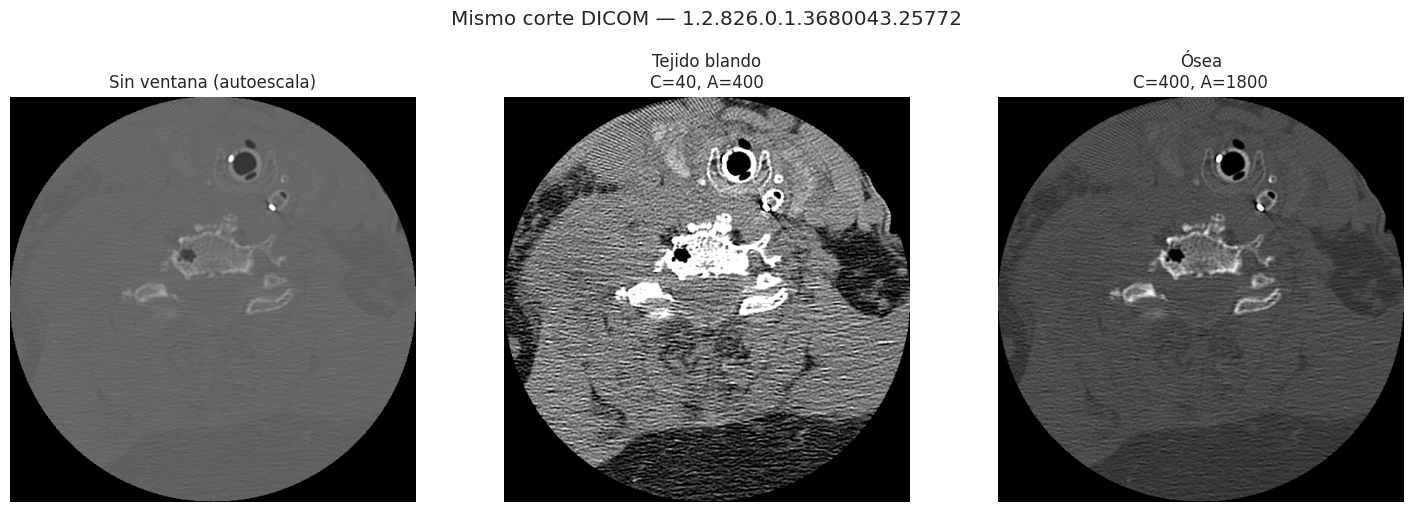

**Interpretación.** Una única escala de grises no representa de forma útil todo el rango HU. La ventana de tejido blando resalta músculos y tejidos vecinos, mientras la ósea conserva contraste en cortical y trabécula, por lo que es la vista apropiada para buscar discontinuidades compatibles con fractura.

In [5]:
example_box = bbox.sort_values(["StudyInstanceUID", "slice_number"]).iloc[len(bbox) // 2]
example_uid = str(example_box["StudyInstanceUID"])
example_path = dicom_for_instance(example_uid, example_box["slice_number"])
hu = cargar_hu(example_path)

views = [
    (hu, "Sin ventana (autoescala)"),
    (ventana(hu, 40, 400), "Tejido blando\nC=40, A=400"),
    (ventana(hu, 400, 1800), "Ósea\nC=400, A=1800"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (image, title) in zip(axes, views):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"Mismo corte DICOM — {example_uid}", y=1.02)
fig.tight_layout()
guardar(fig, "04_comparacion_ventanas.png")
plt.show()

display(Markdown(
    "**Interpretación.** Una única escala de grises no representa de forma útil todo "
    "el rango HU. La ventana de tejido blando resalta músculos y tejidos vecinos, "
    "mientras la ósea conserva contraste en cortical y trabécula, por lo que es la "
    "vista apropiada para buscar discontinuidades compatibles con fractura."
))

## 2. Bounding box sobre el corte anotado

Figura guardada: /kaggle/working/figures/04_bounding_box_corte.png


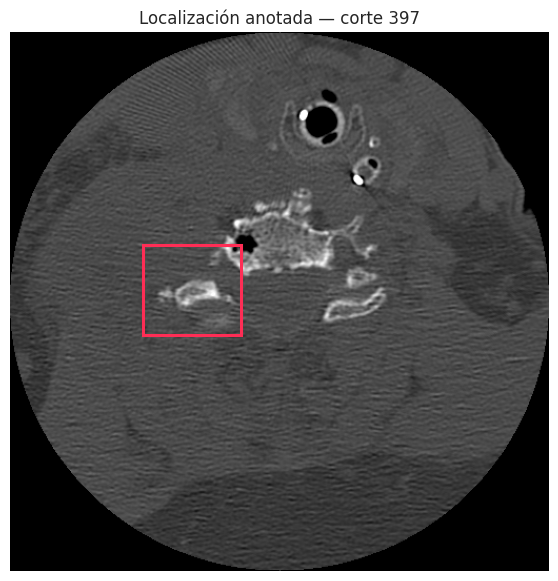

**Interpretación.** Las cajas mostradas ocupan en conjunto 3.016% del corte. La anotación hace visible una región que, sin localización, compite con más de 260 mil píxeles del campo de visión.

In [6]:
same_slice = bbox[
    bbox["StudyInstanceUID"].astype(str).eq(example_uid)
    & bbox["slice_number"].eq(example_box["slice_number"])
]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(ventana(hu, 400, 1800), cmap="gray", vmin=0, vmax=1)
for row in same_slice.itertuples():
    ax.add_patch(Rectangle(
        (row.x, row.y), row.width, row.height,
        fill=False, edgecolor="#ff2d55", linewidth=2.2,
    ))
ax.set(title=f"Localización anotada — corte {int(example_box['slice_number'])}")
ax.axis("off")
guardar(fig, "04_bounding_box_corte.png")
plt.show()

area_pct = 100 * (same_slice["width"] * same_slice["height"]).sum() / hu.size
display(Markdown(
    f"**Interpretación.** Las cajas mostradas ocupan en conjunto {area_pct:.3f}% del "
    "corte. La anotación hace visible una región que, sin localización, compite con "
    "más de 260 mil píxeles del campo de visión."
))

## 3. Reconstrucciones sagital y coronal

El volumen se ordena por ImagePositionPatient[2], no por nombre de archivo.
Para limitar memoria se usa un corte de cada dos; esta reducción es solo visual.

Figura guardada: /kaggle/working/figures/04_reconstruccion_multiplanar.png


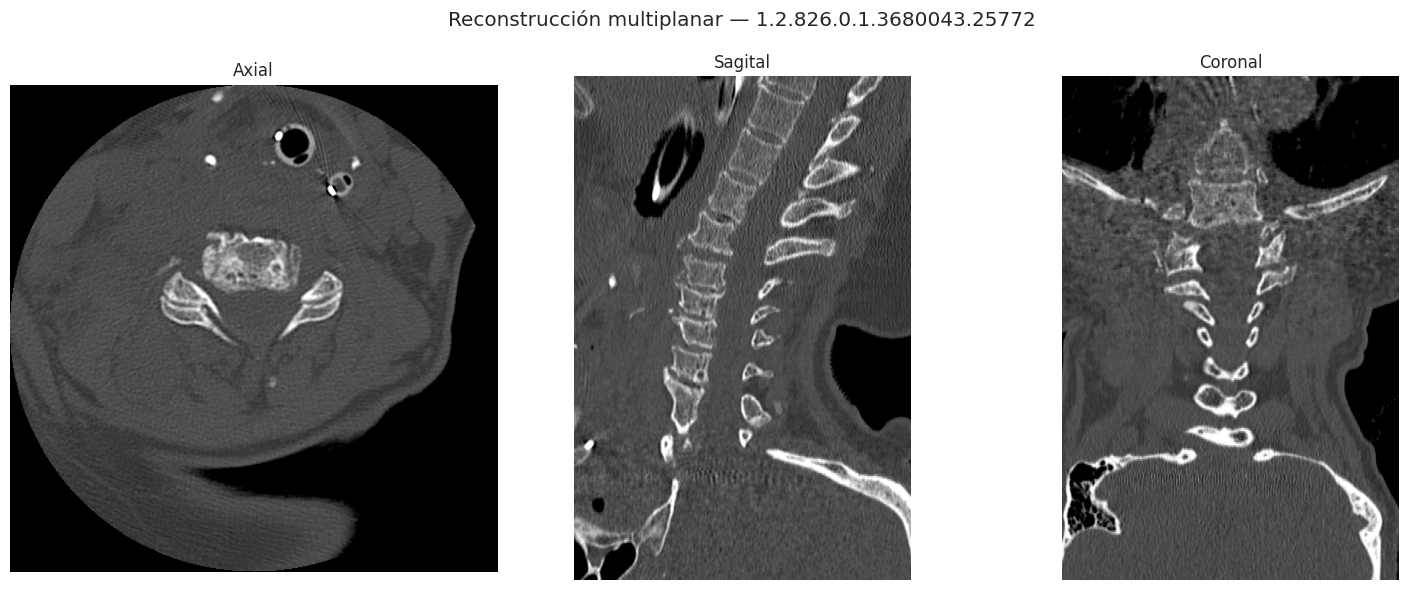

**Interpretación.** La vista axial corresponde a la adquisición original; las vistas sagital y coronal integran la pila ordenada por posición z. Sus proporciones se ajustaron con PixelSpacing y la separación real entre cortes para evitar deformaciones geométricas. La vista sagital permite evaluar continuidad y alineación cervical a lo largo del eje craneocaudal.

In [7]:
recon_uid = example_uid
volume_step = 2
ordered_paths = cortes_ordenados(recon_uid, images_dir=TRAIN_IMAGES)
volume = cargar_volumen(recon_uid, paso=volume_step, images_dir=TRAIN_IMAGES)
z_mid, y_mid, x_mid = np.array(volume.shape) // 2

header0 = pydicom.dcmread(ordered_paths[0], stop_before_pixels=True)
pixel_spacing = np.asarray(getattr(header0, "PixelSpacing", [1.0, 1.0]), dtype=float)
if len(ordered_paths) > 1:
    header1 = pydicom.dcmread(
        ordered_paths[1], stop_before_pixels=True,
        specific_tags=["ImagePositionPatient", "SliceThickness"],
    )
    z0 = float(header0.ImagePositionPatient[2])
    z1 = float(header1.ImagePositionPatient[2])
    z_spacing = abs(z1 - z0)
else:
    z_spacing = float(getattr(header0, "SliceThickness", 1.0))
z_spacing *= volume_step

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(
    ventana(volume[z_mid], 400, 1800), cmap="gray", vmin=0, vmax=1,
    extent=[0, volume.shape[2] * pixel_spacing[1],
            volume.shape[1] * pixel_spacing[0], 0],
)
axes[0].set_title("Axial")
axes[1].imshow(
    ventana(volume[:, :, x_mid], 400, 1800), cmap="gray", vmin=0, vmax=1,
    extent=[0, volume.shape[1] * pixel_spacing[0], volume.shape[0] * z_spacing, 0],
    aspect="equal",
)
axes[1].set_title("Sagital")
axes[2].imshow(
    ventana(volume[:, y_mid, :], 400, 1800), cmap="gray", vmin=0, vmax=1,
    extent=[0, volume.shape[2] * pixel_spacing[1], volume.shape[0] * z_spacing, 0],
    aspect="equal",
)
axes[2].set_title("Coronal")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Reconstrucción multiplanar — {recon_uid}", y=.98)
fig.tight_layout()
guardar(fig, "04_reconstruccion_multiplanar.png")
plt.show()

display(Markdown(
    "**Interpretación.** La vista axial corresponde a la adquisición original; las "
    "vistas sagital y coronal integran la pila ordenada por posición z. Sus proporciones "
    "se ajustaron con PixelSpacing y la separación real entre cortes para evitar "
    "deformaciones geométricas. La vista sagital permite evaluar continuidad y "
    "alineación cervical a lo largo del eje craneocaudal."
))
del volume

## 4. Máscara de segmentación sobre la anatomía

**Control obligatorio:** antes de reutilizar esta máscara, verifica que cada color
siga la vértebra correspondiente. Si aparece espejada o invertida, detén el análisis
y revisa el affine y la transformación en src/io_dicom.py.

Forma DICOM: (208, 512, 512); forma máscara orientada: (208, 512, 512)
Figura guardada: /kaggle/working/figures/04_superposicion_segmentacion.png


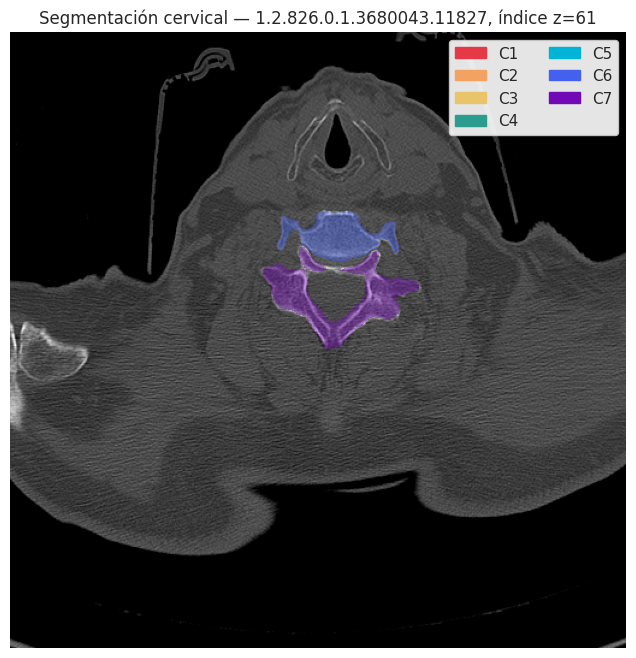

**Validación visual obligatoria.** Antes de usar esta figura, confirma que los colores permanezcan dentro de los cuerpos y arcos vertebrales, sin reflejo izquierda–derecha ni inversión craneocaudal. La coincidencia de dimensiones por sí sola no demuestra alineación; la superposición anatómica debe ser visible.

In [8]:
seg_uid = overlap_uids[0]
seg = cargar_segmentacion(seg_uid, segmentations_dir=SEGMENTATIONS)
seg_volume = cargar_volumen(seg_uid, images_dir=TRAIN_IMAGES)
print(f"Forma DICOM: {seg_volume.shape}; forma máscara orientada: {seg.shape}")
if seg.shape != seg_volume.shape:
    raise ValueError(
        "La máscara y el DICOM no tienen la misma forma. No se remuestrea automáticamente "
        "porque hacerlo sin respetar los affines podría producir una alineación falsa."
    )

slice_scores = np.count_nonzero((seg >= 1) & (seg <= 7), axis=(1, 2))
seg_z = int(slice_scores.argmax())
colors = ["#00000000", "#e63946", "#f4a261", "#e9c46a", "#2a9d8f",
          "#00b4d8", "#4361ee", "#7209b7"]
cmap = mcolors.ListedColormap(colors)
masked = np.ma.masked_where((seg[seg_z] < 1) | (seg[seg_z] > 7), seg[seg_z])

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(ventana(seg_volume[seg_z], 400, 1800), cmap="gray", vmin=0, vmax=1)
ax.imshow(masked, cmap=cmap, vmin=0, vmax=7, alpha=.42, interpolation="nearest")
handles = [mpatches.Patch(color=colors[i], label=f"C{i}") for i in range(1, 8)]
ax.legend(handles=handles, loc="upper right", ncol=2, framealpha=.9)
ax.set(title=f"Segmentación cervical — {seg_uid}, índice z={seg_z}")
ax.axis("off")
guardar(fig, "04_superposicion_segmentacion.png")
plt.show()

display(Markdown(
    "**Validación visual obligatoria.** Antes de usar esta figura, confirma que los "
    "colores permanezcan dentro de los cuerpos y arcos vertebrales, sin reflejo "
    "izquierda–derecha ni inversión craneocaudal. La coincidencia de dimensiones por "
    "sí sola no demuestra alineación; la superposición anatómica debe ser visible."
))
del seg, seg_volume

## 5. Casos positivos frente a negativos

Se comparan cortes en ventana ósea. Para positivos se usan cortes anotados; para
negativos se usa el corte central. La selección no pretende medir desempeño humano,
sino ilustrar que la etiqueta no suele ser evidente sin recorrer el volumen.

Figura guardada: /kaggle/working/figures/04_positivos_vs_negativos.png


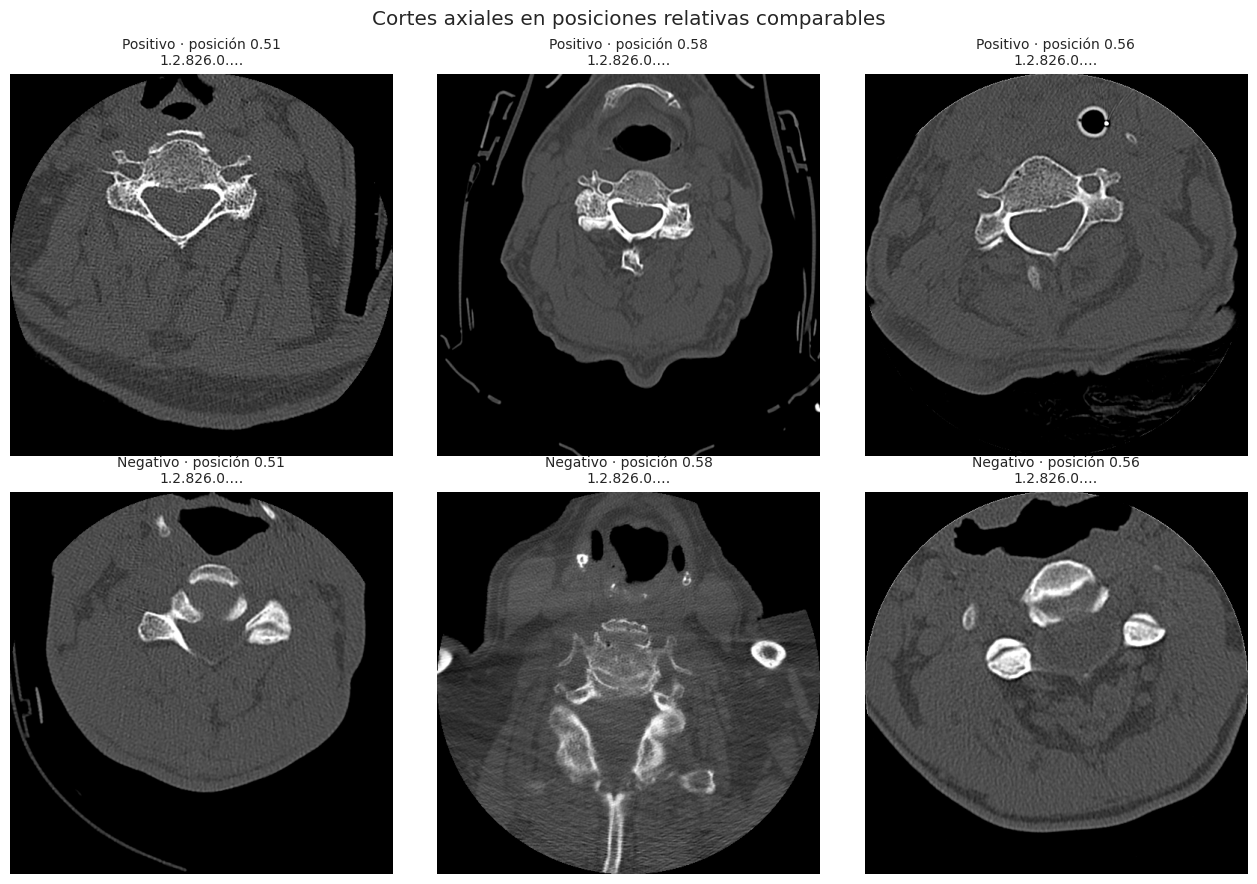

**Interpretación.** Los negativos se seleccionaron en posiciones relativas de la pila comparables a las de los cortes positivos anotados, reduciendo —aunque no eliminando— las diferencias de cobertura anatómica. A esta escala la discontinuidad puede seguir siendo sutil, lo que ilustra la necesidad de contexto 3D y localización. La cuadrícula es demostrativa y no constituye una evaluación diagnóstica.

In [9]:
positive_rows = (
    bbox.assign(StudyInstanceUID=bbox["StudyInstanceUID"].astype(str))
    .drop_duplicates("StudyInstanceUID")
    .sort_values("StudyInstanceUID")
    .head(3)
)
negative_uids = (
    train.loc[train.patient_overall.eq(0), "StudyInstanceUID"]
    .astype(str).sort_values().head(3).tolist()
)

def instance_index(paths, target_instance):
    for index, path in enumerate(paths):
        header = pydicom.dcmread(path, stop_before_pixels=True,
                                 specific_tags=["InstanceNumber"])
        if int(getattr(header, "InstanceNumber", -1)) == int(target_instance):
            return index
    raise ValueError(f"No se encontró InstanceNumber={target_instance}")

examples, relative_positions = [], []
for row in positive_rows.itertuples():
    paths = cortes_ordenados(row.StudyInstanceUID, images_dir=TRAIN_IMAGES)
    index = instance_index(paths, row.slice_number)
    relative = index / max(len(paths) - 1, 1)
    image = cargar_hu(paths[index])
    examples.append((image, f"Positivo · posición {relative:.2f}\n{row.StudyInstanceUID[:10]}…"))
    relative_positions.append(relative)

for uid, relative in zip(negative_uids, relative_positions):
    paths = cortes_ordenados(uid, images_dir=TRAIN_IMAGES)
    index = round(relative * (len(paths) - 1))
    image = cargar_hu(paths[index])
    examples.append((image, f"Negativo · posición {relative:.2f}\n{uid[:10]}…"))

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, (image, title) in zip(axes.flat, examples):
    ax.imshow(ventana(image, 400, 1800), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.suptitle("Cortes axiales en posiciones relativas comparables", y=.98)
fig.tight_layout()
guardar(fig, "04_positivos_vs_negativos.png")
plt.show()

display(Markdown(
    "**Interpretación.** Los negativos se seleccionaron en posiciones relativas de la "
    "pila comparables a las de los cortes positivos anotados, reduciendo —aunque no "
    "eliminando— las diferencias de cobertura anatómica. A esta escala la discontinuidad "
    "puede seguir siendo sutil, lo que ilustra la necesidad de contexto 3D y localización. "
    "La cuadrícula es demostrativa y no constituye una evaluación diagnóstica."
))

## Conclusión

Las figuras demuestran tres decisiones de preprocesamiento: conversión a HU,
ventana ósea y ordenamiento anatómico del volumen. También justifican conservar
contexto tridimensional y utilizar segmentaciones o detectores para centrar el
análisis en C1–C7.